In [117]:
!pip install -q python-igraph scikit-learn ripser persim openTSNE

In [118]:
import torch
from torch.utils.data import Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# Define the transformation pipeline:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),  # Binarize the image
    transforms.Lambda(lambda x: x.view(-1))           # Flatten into a 784-dim vector
])

# Load the training set (set download=True if running for the first time)
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Get indices for images where the label is 1
indices = (mnist_train.targets == 1).nonzero().squeeze()

# Create a subset containing only the '1's
mnist_train_ones = Subset(mnist_train, indices)

print(f"Total number of '1' images in the training set: {len(mnist_train_ones)}")

# Stack all 784-dim vectors from the filtered dataset
all_vectors = torch.stack([img for img, _ in mnist_train_ones])
unique_vectors = torch.unique(all_vectors, dim=0)

print(f"Total images in mnist_train_ones: {all_vectors.shape[0]}")
print(f"Unique images: {unique_vectors.shape[0]}")

if all_vectors.shape[0] == unique_vectors.shape[0]:
    print("All 784-dimensional vectors are unique.")
else:
    print("There are duplicates in the 784-dimensional vectors.")

vectors_np = unique_vectors.numpy()

Total number of '1' images in the training set: 6742
Total images in mnist_train_ones: 6742
Unique images: 6726
There are duplicates in the 784-dimensional vectors.


In [119]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import igraph as ig

def build_weighted_filtered_knn_graph(X, k, max_distance=6.0):
    """
    Builds an undirected k-NN graph on `unique_vectors` but only keeps edges
    whose Euclidean length ≤ max_distance.  Each edge gets a 'weight' attribute
    equal to its Euclidean distance.

    Parameters
    ----------
    unique_vectors : array-like, shape (n, d)
        Your dataset (can be a numpy array or a torch tensor with .numpy()).
    k : int
        The number of nearest neighbours to consider per point.
    max_distance : float
        The distance threshold for pruning edges.

    Returns
    -------
    g : igraph.Graph
        An undirected graph on n vertices with only the filtered edges, and
        g.es['weight'] giving each edge’s Euclidean length.
    """
    n = X.shape[0]
    print(f"Building weighted filtered k-NN graph for {n} nodes with edge dist ≤ {max_distance}...")

    # find k+1 neighbors (including self)
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    distances, indices = nbrs.kneighbors(X)

    edge_list = []
    weight_list = []
    for i, (neighbors, dists) in enumerate(zip(indices, distances)):
        # skip the first neighbor (itself)
        for j, dist in zip(neighbors[1:], dists[1:]):
            # only add each edge once (i<j) and only if within threshold
            if dist <= max_distance and i < j:
                edge_list.append((i, j))
                weight_list.append(dist)

    # build igraph and assign weights
    g = ig.Graph(n=n, edges=edge_list, directed=False)
    g.es['weight'] = weight_list

    print(f"Graph built: {n} vertices, {g.ecount()} edges.")
    return g

g_weighted = build_weighted_filtered_knn_graph(vectors_np, k=5, max_distance=6)


Building weighted filtered k-NN graph for 6726 nodes with edge dist ≤ 6...
Graph built: 6726 vertices, 15068 edges.


In [120]:
# find all connected components
components = g_weighted.clusters()    # or g_weighted.components()

# extract the subgraph of the largest one
g_largest = components.giant()

print(f"Largest component has {g_largest.vcount()} vertices and {g_largest.ecount()} edges")


Largest component has 6372 vertices and 15015 edges


<ipython-input-120-facadf845211>:2: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  components = g_weighted.clusters()    # or g_weighted.components()


In [121]:
import random
import numpy as np

def find_max_fold_pair_in_largest_component(g, vectors_np, num_pairs=1000, seed=None):
    """
    Samples random node‐pairs *within the largest connected component* of g
    and returns the pair (i,j) that maximizes
        Δ = geodesic_distance(i,j) − euclidean_distance(i,j).

    Parameters
    ----------
    g : igraph.Graph
        Undirected graph on your data, with edge attribute 'weight' = Euclidean length.
    vectors_np : np.ndarray, shape (n, d)
        Your original data points in R^d.
    num_pairs : int
        How many random pairs to sample (default 1000).
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    (i_star, j_star), delta_star : (int, int), float
        The original‐index pair in the largest component with the largest Δ.
    """
    # 1) find the largest connected component
    comp = g.connected_components()  # or g.components() in newer igraph
    # pick the cluster ID of the largest component
    largest_cid = comp.sizes().index(max(comp.sizes()))
    # build the list of vertex‐indices in that component
    nodes = [vid for vid, cid in enumerate(comp.membership) if cid == largest_cid]

    rng = random.Random(seed)
    best_pair = None
    best_delta = -np.inf

    for _ in range(num_pairs):
        i, j = rng.sample(nodes, 2)

        # 1) geodesic distance along the graph
        geo = g.distances(i, j, weights='weight')[0][0]

        # 2) straight‐line Euclidean distance
        euc = np.linalg.norm(vectors_np[i] - vectors_np[j])

        delta = geo - euc
        if delta > best_delta:
            best_delta = delta
            best_pair = (i, j)

    print(f"Largest residual‐fold between {best_pair[0]} and {best_pair[1]}, Δ = {best_delta:.3f}")

    return best_pair, best_delta


In [122]:
# assuming g_weighted is your full weighted KNN graph and vectors_np your data:
(i_max, j_max), Δ_max = find_max_fold_pair_in_largest_component(
    g_weighted, vectors_np, num_pairs=5000, seed=42
)
print(f"Largest fold between {i_max} and {j_max}, Δ = {Δ_max:.3f}")


Largest residual‐fold between 2346 and 3290, Δ = 109.567
Largest fold between 2346 and 3290, Δ = 109.567


In [123]:
import numpy as np

def compute_uncrumpling_axis(vectors, i, j):
    """
    Compute the normalized axis vector between two indices in the dataset.

    Parameters
    ----------
    vectors : np.ndarray, shape (N, D)
        Array of data points.
    i, j : int
        Indices of the two endpoints.

    Returns
    -------
    axis : np.ndarray, shape (D,)
        The unit vector pointing from vectors[i] to vectors[j].
    """
    xi = vectors[i]
    xj = vectors[j]
    axis = xj - xi
    norm = np.linalg.norm(axis)
    if norm == 0:
        raise ValueError(f"Points at indices {i} and {j} are identical; axis is zero-length.")
    return axis / norm

# Example usage:
axis1 = compute_uncrumpling_axis(vectors_np, i_max, j_max)
print("Axis 1 shape:", axis1.shape)


Axis 1 shape: (784,)


In [124]:
import numpy as np

def project_onto_axes(vectors, axes):
    """
    Project each row of `vectors` onto the subspace spanned by `axes`.

    Parameters
    ----------
    vectors : np.ndarray, shape (N, D)
        Your data points.
    axes : np.ndarray, shape (K, D)
        Orthonormal axis vectors (one per row).

    Returns
    -------
    coords : np.ndarray, shape (N, K)
        coords[i, j] = dot(vectors[i], axes[j])
    """
    # ensure axes is (K, D)
    A = np.asarray(axes)
    return vectors.dot(A.T)


def compute_residuals(vectors, axes):
    """
    Compute the residuals of `vectors` after projecting onto `axes`.

    Parameters
    ----------
    vectors : np.ndarray, shape (N, D)
    axes : np.ndarray, shape (K, D)
        Orthonormal axis vectors.

    Returns
    -------
    residuals : np.ndarray, shape (N, D)
        residuals[i] = vectors[i] - sum_j coords[i,j] * axes[j]
    """
    coords = project_onto_axes(vectors, axes)   # (N, K)
    A = np.asarray(axes)                       # (K, D)
    # reconstruct the projection
    projected = coords.dot(A)                  # (N, D)
    return vectors - projected

def getProjectedAndResiduals(vectors, axes):
    # project all points
    coords1 = project_onto_axes(vectors_np, axes)   # shape (N, 1)

    # get the residuals
    residual = compute_residuals(vectors_np, axes)     # shape (N, D)

    return coords1, residual

In [125]:
# suppose v1 is your first unit-axis of shape (D,)
axes = np.array([axis1])       # shape (1, D)

coords1, residual = getProjectedAndResiduals(vectors_np, axes)


In [126]:
# 1) Build a new graph on the residuals, not the originals
graph2 = build_weighted_filtered_knn_graph(residual, k=5, max_distance=6.0)

# 2) Find the biggest fold *in the residual manifold*
(i2, j2), delta2 = find_max_fold_pair_in_largest_component(
    graph2,
    residual,
    num_pairs=5000,
    seed=42
)

# 3) Extract the second axis from the residuals
axis2 = compute_uncrumpling_axis(residual, i2, j2)  # shape (D,)

# 4) Stack both axes into a (2, D) array
axes = np.vstack([axis1, axis2])   # axis1 was your first (D,), axis2 the second

# 5) Project & compute the new residuals
coords2, residual2 = getProjectedAndResiduals(residual, axes)


Building weighted filtered k-NN graph for 6726 nodes with edge dist ≤ 6.0...
Graph built: 6726 vertices, 16611 edges.
Largest residual‐fold between 122 and 6100, Δ = 78.504


In [141]:
def single_source_deltas_radius(p, X, A_csr):
    """
    Compute Δ_i = dG(p,i) - dE(p,i) using a pure-radius adjacency.
    """
    # 1) Geodesic: shortest-paths on the radius‐graph
    dG = dijkstra(A_csr, directed=False, indices=p)

    # 2) Euclidean: straight‐line
    dE = np.linalg.norm(X - X[p], axis=1)

    # 3) Mask unreachable (dG == inf) and self
    valid = np.isfinite(dG)
    deltas = np.full_like(dG, -np.inf)
    deltas[valid] = dG[valid] - dE[valid]
    deltas[p] = -np.inf

    return deltas

In [128]:
import numpy as np

def extract_pivots(residuals, num_pivots=100):
    """
    Select pivot indices based on the highest residual norms.

    Parameters
    ----------
    residuals : np.ndarray, shape (N, D)
        The current residual vectors for each data point.
    num_pivots : int
        Number of pivot indices to select.

    Returns
    -------
    pivots : list of int
        Indices of the points with the largest residual norms, sorted descending by norm.
    """
    # Compute L2 norm of each residual vector
    norms = np.linalg.norm(residuals, axis=1)

    # If num_pivots >= number of points, return all indices sorted by norm
    N = norms.shape[0]
    if num_pivots >= N:
        return list(np.argsort(-norms))

    # Get the indices of the top num_pivots norms
    # Use argpartition for efficiency
    top_idx = np.argpartition(norms, -num_pivots)[-num_pivots:]

    # Sort those top indices by descending norm
    top_idx_sorted = top_idx[np.argsort(-norms[top_idx])]

    return top_idx_sorted.tolist()

# Example usage:
# residuals = final_residual  # np.ndarray of shape (N, D)
# pivots = extract_pivots(residuals, num_pivots=200)
# print("Selected pivot indices:", pivots)


In [145]:
import numpy as np

def find_max_fold_pair_pivots_radius(X, A_csr, pivots, second_sweep=True):
    """
    Pivot-based search using a pure-radius adjacency graph.

    For each pivot p, compute Δ = d_G(p,i) - d_E(p,i) via single_source_deltas_radius,
    ignoring unreachable nodes. Optionally perform a second sweep from the best-found j.

    Parameters
    ----------
    X : np.ndarray, shape (N, D)
        Data points.
    A_csr : scipy.sparse.csr_matrix, shape (N, N)
        Radius-based adjacency with distances as weights.
    pivots : array-like of int
        Indices of pivot nodes.
    second_sweep : bool
        Whether to do a second Dijkstra sweep from the best endpoint.

    Returns
    -------
    best_pair : (int, int)
        Pivot and its best counterpart maximizing Δ.
    best_delta : float
        The maximal Δ found.
    """
    best_pair = None
    best_delta = -np.inf

    # First sweep: from each pivot
    for p in pivots:
        deltas = single_source_deltas_radius(p, X, A_csr)
        j = int(np.argmax(deltas))
        if deltas[j] > best_delta:
            best_delta = deltas[j]
            best_pair = (p, j)

    # Optional second sweep from the best paired endpoint
    if second_sweep and best_pair is not None:
        p0 = best_pair[1]
        deltas = single_source_deltas_radius(p0, X, A_csr)
        j = int(np.argmax(deltas))
        if deltas[j] > best_delta:
            best_delta = deltas[j]
            best_pair = (p0, j)

    return best_pair, best_delta


In [146]:
import numpy as np
from sklearn.neighbors import radius_neighbors_graph

def uncrumple(
    vectors_np,
    max_distance=6.0,
    max_axes=10,
    delta_tol=None,
    num_pivots=200,
    second_sweep=True,
    var_tol=0.01,
    seed=None
):
    """
    Iteratively 'uncrumples' a manifold using a pure-radius graph.

    Parameters
    ----------
    vectors_np : np.ndarray, shape (N, D)
        Original data points in R^D.
    max_distance : float
        Radius threshold for connecting points in the graph.
    max_axes : int
        Hard cap on the number of axes (iterations) to extract.
    delta_tol : float or None
        Stopping threshold on fold size Δ; defaults to max_distance.
    num_pivots : int
        Number of high-residual pivots to use per iteration.
    second_sweep : bool
        Whether to do a second pivot sweep from the best endpoint.
    var_tol : float
        Fraction of original variance left below which to stop.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    coords_matrix : np.ndarray, shape (N, M)
        Projection coordinates of each point onto the M extracted axes.
    axes : np.ndarray, shape (M, D)
        Orthonormal uncrumpling axes in R^D.
    deltas : list of float
        Sequence of maximal fold sizes Δ at each iteration.
    residual : np.ndarray, shape (N, D)
        Final residual vectors after removing all components.
    resid_ratios : list of float
        Fraction of original variance left after each axis.
    """
    import random
    from scipy.sparse import csr_matrix

    N, D = vectors_np.shape
    residual = vectors_np.copy()
    orig_norm2 = np.sum(vectors_np**2)
    if delta_tol is None:
        delta_tol = max_distance

    axes_list = []
    coords_list = []
    deltas = []
    resid_ratios = []

    for it in range(max_axes):
        print(f"Iteration {it+1}/{max_axes}:")
        print(f"  Building pure-radius graph (radius={max_distance})...")
        A = radius_neighbors_graph(
            residual,
            radius=max_distance,
            mode='distance',
            include_self=False
        )
        A_csr = csr_matrix(A)

        # select pivots by top residual norms
        pivots = extract_pivots(residual, num_pivots)

        print(f"  Searching {len(pivots)} pivots for max fold...")
        (i, j), delta = find_max_fold_pair_pivots_radius(
            residual, A_csr, pivots, second_sweep
        )
        print(f"  Max Δ = {delta:.4f} between nodes {i} and {j}")

        if delta < delta_tol:
            print(f"  Δ = {delta:.4f} < delta_tol = {delta_tol}. Stopping.")
            break

        # extract and orthonormalize new axis
        axis = compute_uncrumpling_axis(residual, i, j)
        for prev in axes_list:
            axis -= np.dot(axis, prev) * prev
        axis /= np.linalg.norm(axis)
        axes_list.append(axis)

        # project and remove component
        coords = residual.dot(axis)
        coords_list.append(coords)
        residual = residual - np.outer(coords, axis)
        deltas.append(delta)

        # compute and check residual variance ratio
        resid_norm2 = np.sum(residual**2)
        frac_left = resid_norm2 / orig_norm2
        resid_ratios.append(frac_left)
        print(f"  Residual variance ratio: {frac_left:.4f}")
        if frac_left < var_tol:
            print(f"  Variance ratio {frac_left:.4f} < var_tol {var_tol}. Stopping.")
            break

        print(f"  Axis {it+1} extracted. Residual norm: {np.linalg.norm(residual):.4f}")

    axes = np.vstack(axes_list) if axes_list else np.zeros((0, D))
    coords_matrix = np.column_stack(coords_list) if coords_list else np.zeros((N, 0))
    return coords_matrix, axes, deltas, residual, resid_ratios


In [ ]:
coords_matrix, axes, deltas, final_residual, percentage_resid = uncrumple(
    vectors_np,
    max_distance=6.0,
    max_axes=10,
    delta_tol=6,
    num_pivots=250,
    second_sweep=True,
    var_tol=0.01,
    seed=42
)

Iteration 1/10:
  Building pure-radius graph (radius=6.0)...
  Searching 250 pivots for max fold...


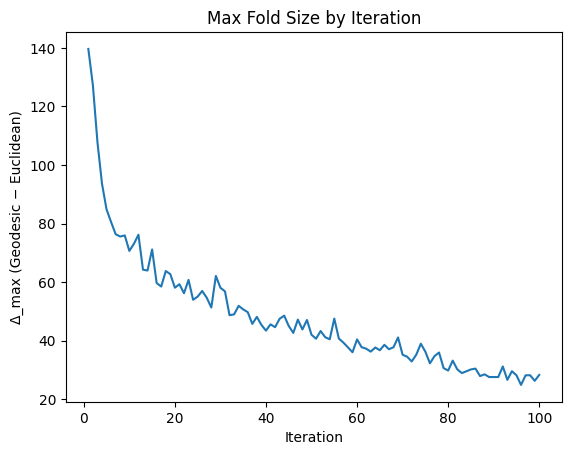

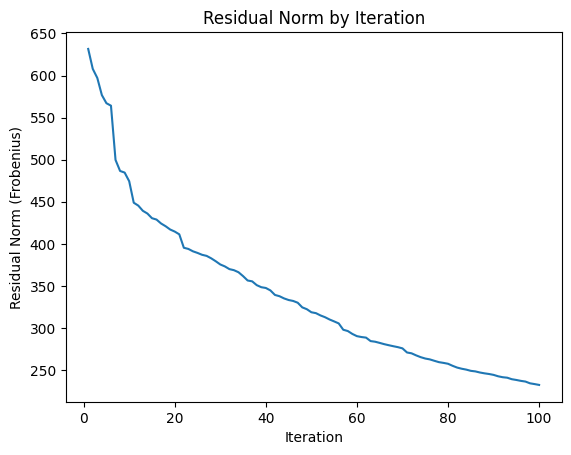

In [136]:
import numpy as np
import matplotlib.pyplot as plt

# deltas: list of Δ_max from each iteration
# coords_matrix: shape (N, M) of projection coordinates
# axes:          shape (M, D) of extracted unit vectors
# vectors_np:    shape (N, D) original data

deltas_arr = np.array(deltas)
M = len(deltas_arr)
iters = np.arange(1, M+1)

# 1) Compute residual‐norms after each axis
residual_norms = []
for m in range(M):
    # reconstruct using first m+1 axes
    C = coords_matrix[:, :m+1]    # (N, m+1)
    A = axes[:m+1, :]            # (m+1, D)
    approx = C.dot(A)             # (N, D)
    resid = vectors_np - approx   # (N, D)
    residual_norms.append(np.linalg.norm(resid))
residual_norms = np.array(residual_norms)

# 2) Plot Δ_max vs iteration
plt.figure()
plt.plot(iters, deltas_arr)
plt.xlabel('Iteration')
plt.ylabel('Δ_max (Geodesic − Euclidean)')
plt.title('Max Fold Size by Iteration')

# 3) Plot residual norm vs iteration
plt.figure()
plt.plot(iters, residual_norms)
plt.xlabel('Iteration')
plt.ylabel('Residual Norm (Frobenius)')
plt.title('Residual Norm by Iteration')

# 4) Plot fraction of residual
# plt.figure()
# plt.plot(iters, percentage_resid)
# plt.xlabel('Iteration')
# plt.ylabel('Residual Norm Percentage')
# plt.title('Residual Norm Percentage')

plt.show()


In [140]:
from sklearn.neighbors import radius_neighbors_graph
from scipy.sparse.csgraph import dijkstra
import numpy as np

# X is your (N, D) array of vectors_np
radius = 6.0

# Build a pure-radius graph: A[i,j] = distance(i,j) if ≤ radius, else 0
radius_neighbors_graph(
    vectors_np,
    radius=radius,
    mode='distance',    # stores the actual distances
    include_self=False
)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9363804 stored elements and shape (6726, 6726)>

In [132]:
# import numpy as np
# import random
# from sklearn.neighbors import NearestNeighbors
# import igraph as ig

# def build_weighted_filtered_knn_graph(X, k, max_distance):
#     """
#     Build a weighted k-NN graph with edges only if distance <= max_distance.
#     """
#     n = X.shape[0]
#     nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
#     distances, indices = nbrs.kneighbors(X)
#     edges = []
#     weights = []
#     for i, (nbr_idx, dists) in enumerate(zip(indices, distances)):
#         for j, dist in zip(nbr_idx[1:], dists[1:]):
#             if i < j and dist <= max_distance:
#                 edges.append((i, j))
#                 weights.append(dist)
#     g = ig.Graph(n=n, edges=edges, directed=False)
#     g.es['weight'] = weights
#     return g

# def compute_uncrumpling_axis(vectors, i, j):
#     """
#     Compute the unit vector from index i to j.
#     """
#     axis = vectors[j] - vectors[i]
#     norm = np.linalg.norm(axis)
#     if norm == 0:
#         raise ValueError("Zero-length axis")
#     return axis / norm

# def find_max_fold_pair_pivots(g, vectors, pivots, second_sweep=True):
#     """
#     Pivot-based search: for each pivot p, find j maximizing dG(p,j)-dE(p,j).
#     Optionally do a second sweep from the best j.
#     """
#     best_pair = None
#     best_delta = -np.inf

#     for p in pivots:
#         dG = np.array(g.distances(p, weights='weight')[0])
#         dE = np.linalg.norm(vectors - vectors[p], axis=1)
#         deltas = dG - dE
#         deltas[p] = -np.inf
#         j = int(np.argmax(deltas))
#         if deltas[j] > best_delta:
#             best_delta = deltas[j]
#             best_pair = (p, j)

#     if second_sweep and best_pair is not None:
#         p0 = best_pair[1]
#         dG = np.array(g.distances(p0, weights='weight')[0])
#         dE = np.linalg.norm(vectors - vectors[p0], axis=1)
#         deltas = dG - dE
#         deltas[p0] = -np.inf
#         j = int(np.argmax(deltas))
#         if deltas[j] > best_delta:
#             best_delta = deltas[j]
#             best_pair = (p0, j)

#     return best_pair, best_delta

# def uncrumple_with_pivots(
#     vectors, k=5, max_distance=6.0, max_axes=10, delta_tol=1.0,
#     num_pivots=100, second_sweep=True, seed=None
# ):
#     """
#     Uncrumple using pivot-based search (high-residual pivots) per iteration.
#     """
#     vectors = np.asarray(vectors)
#     N, D = vectors.shape
#     residual = vectors.copy()
#     axes_list = []
#     coords_list = []
#     deltas = []
#     rng = random.Random(seed)

#     for it in range(max_axes):
#         print(f"Iteration {it+1}/{max_axes}")
#         # Build graph on current residuals
#         graph = build_weighted_filtered_knn_graph(residual, k, max_distance)

#         # Select pivots: top num_pivots by residual norm
#         res_norms = np.linalg.norm(residual, axis=1)
#         pivots = np.argsort(res_norms)[-num_pivots:].tolist()

#         # Pivot-based max fold search
#         (i, j), delta = find_max_fold_pair_pivots(graph, residual, pivots, second_sweep)
#         print(f"  Max Δ = {delta:.4f} between nodes {i},{j}")
#         if delta < delta_tol:
#             print(f"  Δ < {delta_tol}; stopping.")
#             break

#         # Extract and orthonormalize new axis
#         axis = compute_uncrumpling_axis(residual, i, j)
#         for prev in axes_list:
#             axis -= np.dot(axis, prev) * prev
#         axis /= np.linalg.norm(axis)
#         axes_list.append(axis)

#         # Project and subtract
#         coords = residual.dot(axis)
#         coords_list.append(coords)
#         residual = residual - np.outer(coords, axis)
#         deltas.append(delta)
#         print(f"  Residual norm: {np.linalg.norm(residual):.4f}")

#     axes = np.vstack(axes_list) if axes_list else np.zeros((0, D))
#     coords_matrix = np.column_stack(coords_list) if coords_list else np.zeros((N, 0))
#     return coords_matrix, axes, deltas, residual

# coords_matrix, axes, deltas, final_residual = uncrumple_with_pivots(
#     vectors_np,
#     k=5,
#     max_distance=6.0,
#     max_axes=30,
#     delta_tol=1.0,
#     num_pivots=200,
#     second_sweep=True,
#     seed=42
# )

In [133]:
# import numpy as np
# import matplotlib.pyplot as plt

# # deltas: list of Δ_max from each iteration
# # coords_matrix: shape (N, M) of projection coordinates
# # axes:          shape (M, D) of extracted unit vectors
# # vectors_np:    shape (N, D) original data

# deltas_arr = np.array(deltas)
# M = len(deltas_arr)
# iters = np.arange(1, M+1)

# # 1) Compute residual‐norms after each axis
# residual_norms = []
# for m in range(M):
#     # reconstruct using first m+1 axes
#     C = coords_matrix[:, :m+1]    # (N, m+1)
#     A = axes[:m+1, :]            # (m+1, D)
#     approx = C.dot(A)             # (N, D)
#     resid = vectors_np - approx   # (N, D)
#     residual_norms.append(np.linalg.norm(resid))
# residual_norms = np.array(residual_norms)

# # 2) Plot Δ_max vs iteration
# plt.figure()
# plt.plot(iters, deltas_arr)
# plt.xlabel('Iteration')
# plt.ylabel('Δ_max (Geodesic − Euclidean)')
# plt.title('Max Fold Size by Iteration')

# # 3) Plot residual norm vs iteration
# plt.figure()
# plt.plot(iters, residual_norms)
# plt.xlabel('Iteration')
# plt.ylabel('Residual Norm (Frobenius)')
# plt.title('Residual Norm by Iteration')

# plt.show()
